# All-to-all purification times: production run (paper data)

Production study of the **full** ($\tau_\mathrm{full}$: code dimension $k\to 0$)
and **single** ($\tau_p$: reference entropy $\to 0$) purification times, plus the
**tableau density** $\bar a$ (`mean_active_generators`), on the all-to-all
(complete-graph) model: random perfect-matching Cliffords (`brickwork` +
`palette`) and Bernoulli measurements at rate $p$, run `until_purified` with a
depth cap of `DEPTH_FACTOR * n` layers, `hybrid=True`.

**How to run (Windows)**

1. Pull the repo, then in PowerShell from the repo root:
   `py -m venv .venv`, `.venv\Scripts\Activate.ps1`, `pip install -e ".[dev]"`.
2. Launch `jupyter lab` from the activated venv and open this notebook.
3. Run top to bottom once with `PRODUCTION = False` (a ~2-minute smoke pass that
   exercises every cell), then set `PRODUCTION = True` and run again.

**Production safety**

- The run is **chunked and resumable**: one on-disk `Study` per (picture, $n$)
  under `runs/paper_alltoall/`. Finished chunks are skipped on re-run, so an
  interruption only ever costs the chunk in flight. Delete a chunk's folder to
  recompute it.
- Run the **calibration cell** (§2) before the big one; it measures your
  machine and projects the total wall-clock for the configured grid.
- The progress bar advances per completed cell, out of order; long censored
  cells finishing in bursts near the end of a chunk is normal.

In [1]:
import math
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sparsegf2.circuits import CircuitConfig, simulate
from sparsegf2.analysis import Study

plt.rcParams["figure.dpi"] = 115
plt.rcParams["axes.grid"] = True
plt.rcParams["savefig.bbox"] = "tight"

# ----------------------------------------------------------------------
# THE switch. False = ~2-minute smoke pass (same code path, tiny grid).
# ----------------------------------------------------------------------
PRODUCTION = False

if PRODUCTION:
    N_VALS = [32, 64, 128, 256, 512]
    # dense where the transition lives, coarse wings
    P_VALS = sorted(set(
        np.round(np.arange(0.08, 0.301, 0.01), 3).tolist()
        + [0.35, 0.40, 0.45, 0.55, 0.70]
    ))
    SEEDS = {32: 1000, 64: 600, 128: 300, 256: 150, 512: 80}
    DEPTH_FACTOR = 40          # cap = 40 n layers, same scaling at every n
else:
    N_VALS = [16, 24]
    P_VALS = sorted(set(np.round(np.linspace(0.10, 0.45, 8), 3).tolist()))
    SEEDS = {16: 24, 24: 16}
    DEPTH_FACTOR = 30

PICTURES = ["purification", "single_ref"]      # tau_full and tau_p
OUT = Path("runs/paper_alltoall")
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
N_CORES = os.cpu_count()


def base_config(n, picture):
    return CircuitConfig(
        graph_spec="complete", n=n, p=P_VALS[0], picture=picture,
        gating_mode="brickwork", matching_mode="palette",
        measurement_mode="bernoulli",
        depth_mode="until_purified", depth_factor=DEPTH_FACTOR, hybrid=True,
    )


def chunk_dir(picture, n):
    return OUT / f"{picture}_n{n}"


print(f"PRODUCTION={PRODUCTION} | n={N_VALS} | {len(P_VALS)} p-values | "
      f"seeds={SEEDS} | cap={DEPTH_FACTOR}*n layers | {N_CORES} cores")
total_cells = sum(len(P_VALS) * SEEDS[n] for n in N_VALS) * len(PICTURES)
print(f"total cells: {total_cells:,}")


PRODUCTION=False | n=[16, 24] | 8 p-values | seeds={16: 24, 24: 16} | cap=30*n layers | 8 cores
total cells: 640


## 2. Calibration: measure this machine, project the wall-clock

Times one purifying (high-$p$) and one fully **censored** (low-$p$, runs the
whole cap) trajectory at the smallest and largest configured $n$, then projects
the total. Censored cells dominate the budget; the projection brackets the truth
between "no cell is censored" and "every below-crossover cell is censored".

In [2]:
import time

def time_cell(n, p, picture):
    cfg = CircuitConfig(
        graph_spec="complete", n=n, p=p, picture=picture,
        gating_mode="brickwork", matching_mode="palette",
        measurement_mode="bernoulli",
        depth_mode="until_purified", depth_factor=DEPTH_FACTOR, hybrid=True)
    t0 = time.perf_counter()
    rec = simulate(cfg, sample_seed=0)
    return time.perf_counter() - t0, rec

P_HI, P_LO = max(P_VALS), min(P_VALS)
calib = {}
for n in (N_VALS[0], N_VALS[-1]):
    t_fast, _ = time_cell(n, P_HI, "purification")     # warms JIT on first call
    t_fast, _ = time_cell(n, P_HI, "purification")
    t_slow, rec = time_cell(n, P_LO, "purification")
    calib[n] = (t_fast, t_slow)
    print(f"n={n:4d}: purifying(p={P_HI}) {t_fast:7.2f} s | "
          f"low-p(p={P_LO}) {t_slow:7.2f} s "
          f"({'censored, full cap' if rec.purified_at_layer is None else 'purified'})")

# project: interpolate per-cell cost in n (cost ~ n^2 between the two anchors)
def interp_cost(n, idx):
    n0, n1 = N_VALS[0], N_VALS[-1]
    c0, c1 = calib[n0][idx], calib[n1][idx]
    if n1 == n0:
        return c0
    alpha = math.log(max(c1, 1e-9) / max(c0, 1e-9)) / math.log(n1 / n0)
    return c0 * (n / n0) ** alpha

lo = hi = 0.0
for pic in PICTURES:
    for n in N_VALS:
        cells_n = len(P_VALS) * SEEDS[n]
        lo += cells_n * interp_cost(n, 0)                      # all purify fast
        frac_cens = 0.4                                        # ~grid below crossover
        hi += cells_n * ((1 - frac_cens) * interp_cost(n, 0)
                         + frac_cens * interp_cost(n, 1))
par = max(N_CORES - 1, 1)
print(f"\nprojected wall-clock on {N_CORES} cores: "
      f"{lo / par / 3600:.1f} h (best case) ... {hi / par / 3600:.1f} h (typical-to-worst)")
print("If that is too long: cut SEEDS at the largest n, trim P_VALS wings, or lower DEPTH_FACTOR.")


n=  16: purifying(p=0.45)    0.00 s | low-p(p=0.1)    0.02 s (purified)
n=  24: purifying(p=0.45)    0.00 s | low-p(p=0.1)    0.04 s (censored, full cap)

projected wall-clock on 8 cores: 0.0 h (best case) ... 0.0 h (typical-to-worst)
If that is too long: cut SEEDS at the largest n, trim P_VALS wings, or lower DEPTH_FACTOR.


## 3. The production run: chunked + resumable

One `Study` per (picture, $n$). A chunk whose `rows.parquet` exists is loaded,
not recomputed. Crash-only logs land in each chunk's `logs/` folder.

In [3]:
studies = {}
for pic in PICTURES:
    for n in N_VALS:
        d = chunk_dir(pic, n)
        if (d / "rows.parquet").exists():
            studies[(pic, n)] = Study.open(d)
            print(f"[resume] {d}  ({len(studies[(pic, n)])} rows)")
            continue
        print(f"[run]    {d}  ({len(P_VALS) * SEEDS[n]} cells)")
        studies[(pic, n)] = Study.run(
            d, base_config(n, pic),
            grid={"n": [n], "p": P_VALS},      # n in the grid so rows carry it
            seeds=SEEDS[n],
            save_tableaux=False,               # rows only; tableaux would be GBs
            n_jobs=-1, progress=True,
        )
print("all chunks present")


[run]    runs/paper_alltoall/purification_n16  (192 cells)


study:   0%|          | 0/192 [00:00<?, ?step/s]

[run]    runs/paper_alltoall/purification_n24  (128 cells)


study:   0%|          | 0/128 [00:00<?, ?step/s]

[run]    runs/paper_alltoall/single_ref_n16  (192 cells)


study:   0%|          | 0/192 [00:00<?, ?step/s]

[run]    runs/paper_alltoall/single_ref_n24  (128 cells)


study:   0%|          | 0/128 [00:00<?, ?step/s]

all chunks present


## 4. Aggregate statistics

Per $(picture, n, p)$: sample count, **fraction purified** within the cap
(censoring is part of the observable's definition, since the cap is `DEPTH_FACTOR*n`),
mean $\tau$ with SEM **over the purified trajectories only**, median and IQR
(the $\tau$ distribution is heavy-tailed near the transition, so medians are the
robust headline), and mean $\bar a$ with SEM.

In [4]:
df = pd.concat(
    [pd.DataFrame(s.rows) for s in studies.values()], ignore_index=True
)
df["purified"] = df["purified_at_layer"].notna()

def q25(s):
    return s.dropna().quantile(0.25)

def q75(s):
    return s.dropna().quantile(0.75)

agg = (
    df.groupby(["picture", "n", "p"], as_index=False)
      .agg(seeds=("sample_seed", "size"),
           frac_purified=("purified", "mean"),
           mean_tau=("purified_at_layer", lambda s: s.dropna().mean()),
           sem_tau=("purified_at_layer", lambda s: s.dropna().sem()),
           median_tau=("purified_at_layer", lambda s: s.dropna().median()),
           q25_tau=("purified_at_layer", q25),
           q75_tau=("purified_at_layer", q75),
           mean_abar=("mean_active_generators", "mean"),
           sem_abar=("mean_active_generators", "sem"))
)
agg.to_csv(OUT / "aggregate.csv", index=False)
print(f"{len(df):,} trajectories -> {len(agg)} (picture, n, p) cells; "
      f"aggregate saved to {OUT / 'aggregate.csv'}")
agg.head(8)


640 trajectories -> 32 (picture, n, p) cells; aggregate saved to runs/paper_alltoall/aggregate.csv


,picture,n,p,seeds,frac_purified,mean_tau,sem_tau,median_tau,q25_tau,q75_tau,mean_abar,sem_abar
0,purification,16,0.10,24,0.416667,322.300000,33.734931,331.0,246.00,395.25,20.028407,0.310220
1,purification,16,0.15,24,1.000000,131.750000,18.447364,116.5,53.75,179.75,15.485921,0.554571
2,purification,16,0.20,24,1.000000,45.125000,4.839568,40.5,29.25,57.50,11.422330,0.394064
3,purification,16,0.25,24,1.000000,28.583333,3.450959,25.0,17.25,31.75,9.052032,0.321875
4,purification,16,0.30,24,1.000000,13.875000,1.195269,13.0,9.00,16.25,7.103420,0.294707
5,purification,16,0.35,24,1.000000,12.000000,1.017955,10.0,8.75,15.25,6.127926,0.225218
6,purification,16,0.40,24,1.000000,9.875000,0.776261,9.5,7.75,10.50,5.530973,0.196813
7,purification,16,0.45,24,1.000000,7.583333,0.601678,7.5,5.00,9.00,4.870119,0.154302


## 5. Purification time vs $p$ (the headline plots)

Mean $\tau$ (SEM bars) over purified trajectories, log-$y$. Points where the
fraction purified is below 0.99 are drawn **hollow**: there the mean is a lower
bound (censored). Legend shows the seed count per point set.

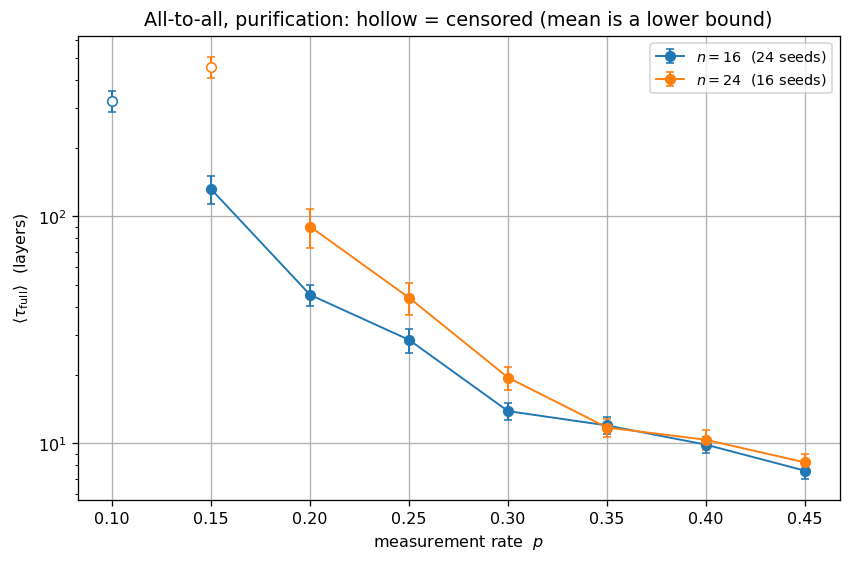

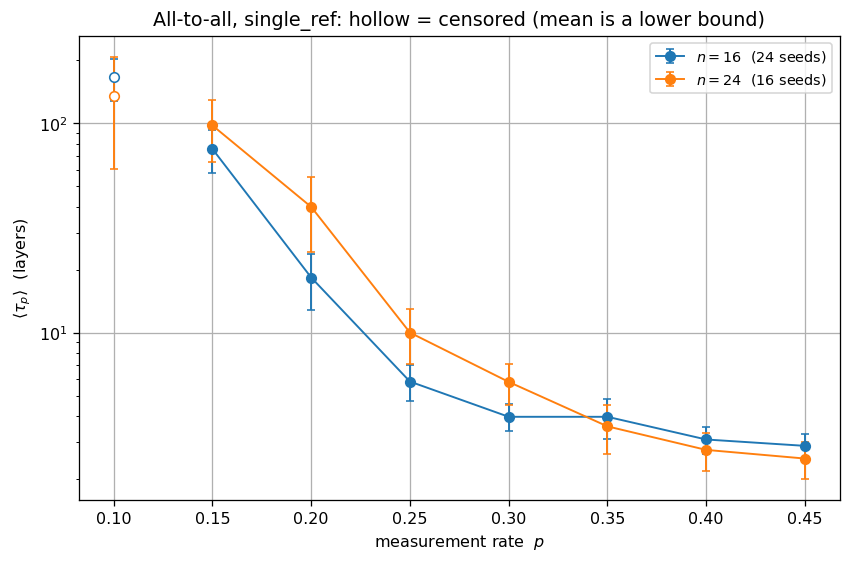

In [5]:
def plot_tau_vs_p(pic, label, fname):
    fig, ax = plt.subplots(figsize=(7.5, 5))
    sub_pic = agg[agg["picture"] == pic]
    for i, (n_val, sub) in enumerate(sub_pic.groupby("n")):
        c = f"C{i}"
        full_pts = sub[sub["frac_purified"] >= 0.99]
        cens_pts = sub[(sub["frac_purified"] < 0.99) & sub["mean_tau"].notna()]
        ax.errorbar(full_pts["p"], full_pts["mean_tau"], yerr=full_pts["sem_tau"],
                    marker="o", capsize=2.5, color=c, lw=1.2,
                    label=f"$n={n_val}$  ({int(sub['seeds'].iloc[0])} seeds)")
        ax.errorbar(cens_pts["p"], cens_pts["mean_tau"], yerr=cens_pts["sem_tau"],
                    marker="o", mfc="white", capsize=2.5, color=c, lw=0, elinewidth=1.2)
    ax.set_yscale("log")
    ax.set(xlabel="measurement rate  $p$", ylabel=label,
           title=f"All-to-all, {pic}: hollow = censored (mean is a lower bound)")
    ax.legend(fontsize=9)
    fig.tight_layout(); fig.savefig(FIG / fname); plt.show()

plot_tau_vs_p("purification", r"$\langle\tau_\mathrm{full}\rangle$  (layers)",
              "tau_full_vs_p.png")
plot_tau_vs_p("single_ref", r"$\langle\tau_p\rangle$  (layers)", "tau_single_vs_p.png")


## 6. Fraction purified vs $p$: the finite-size crossing and $p_c$

$f_n(p)$ = fraction of trajectories that purified within the cap. Curves for
different $n$ cross near $p_c$ (below it, larger systems are *less* likely to
purify in a cap $\propto n$; above it, more likely). The crossing of consecutive
$(n, 2n)$ pairs gives a finite-size estimate of $p_c$.

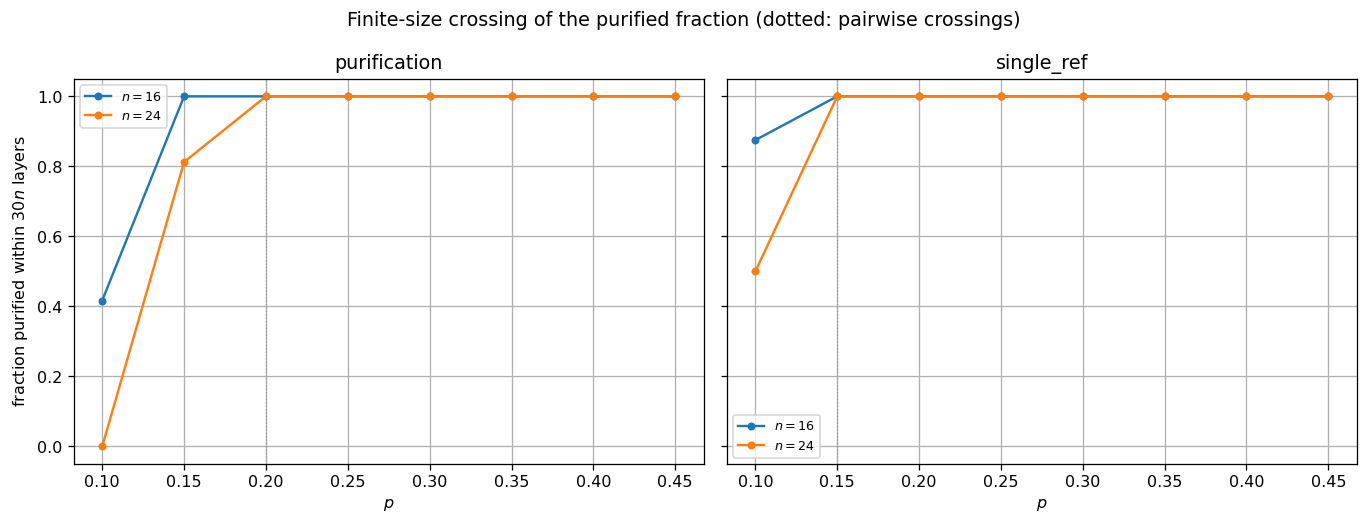

purification: pairwise crossings n=16/24: p=0.200  ->  p_c ~ 0.200 +- 0.000
single_ref: pairwise crossings n=16/24: p=0.150  ->  p_c ~ 0.150 +- 0.000


In [6]:
def crossings(pic):
    sub_pic = agg[agg["picture"] == pic]
    ns = sorted(sub_pic["n"].unique())
    est = []
    for n0, n1 in zip(ns, ns[1:]):
        a = sub_pic[sub_pic["n"] == n0].sort_values("p")
        b = sub_pic[sub_pic["n"] == n1].sort_values("p")
        ps = a["p"].to_numpy()
        d = a["frac_purified"].to_numpy() - b["frac_purified"].to_numpy()
        for k in range(len(ps) - 1):
            if d[k] == 0 or (d[k] > 0) != (d[k + 1] > 0):
                pc = ps[k] if d[k] == 0 else ps[k] + (ps[k + 1] - ps[k]) * abs(d[k]) / (
                    abs(d[k]) + abs(d[k + 1]))
                if 0.02 < d[k] - d[k + 1] or 0.02 < d[k + 1] - d[k]:  # real crossing
                    est.append((n0, n1, pc))
                break
    return est

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, pic in zip(axes, PICTURES):
    sub_pic = agg[agg["picture"] == pic]
    for n_val, sub in sub_pic.groupby("n"):
        ax.plot(sub["p"], sub["frac_purified"], marker="o", ms=4, label=f"$n={n_val}$")
    for n0, n1, pc in crossings(pic):
        ax.axvline(pc, color="0.6", ls=":", lw=0.8)
    ax.set(xlabel="$p$", title=pic)
    ax.legend(fontsize=8)
axes[0].set_ylabel(f"fraction purified within {DEPTH_FACTOR}$n$ layers")
fig.suptitle("Finite-size crossing of the purified fraction (dotted: pairwise crossings)")
fig.tight_layout(); fig.savefig(FIG / "frac_purified_crossing.png"); plt.show()

for pic in PICTURES:
    est = crossings(pic)
    if est:
        vals = [pc for _, _, pc in est]
        print(f"{pic}: pairwise crossings " +
              ", ".join(f"n={a}/{b}: p={c:.3f}" for a, b, c in est) +
              f"  ->  p_c ~ {np.mean(vals):.3f} +- {np.std(vals):.3f}")
    else:
        print(f"{pic}: no crossing inside the p-grid (smoke grids are too small for this)")


## 7. Scaling with system size: $\tau(n)$ at fixed $p$

Semilog-$y$ $\tau$ vs $n$ at selected $p$. Above $p_c$ the growth is slow
(roughly logarithmic for $\tau_p$); near/below $p_c$ it turns exponential,
the dynamical signature of the transition.

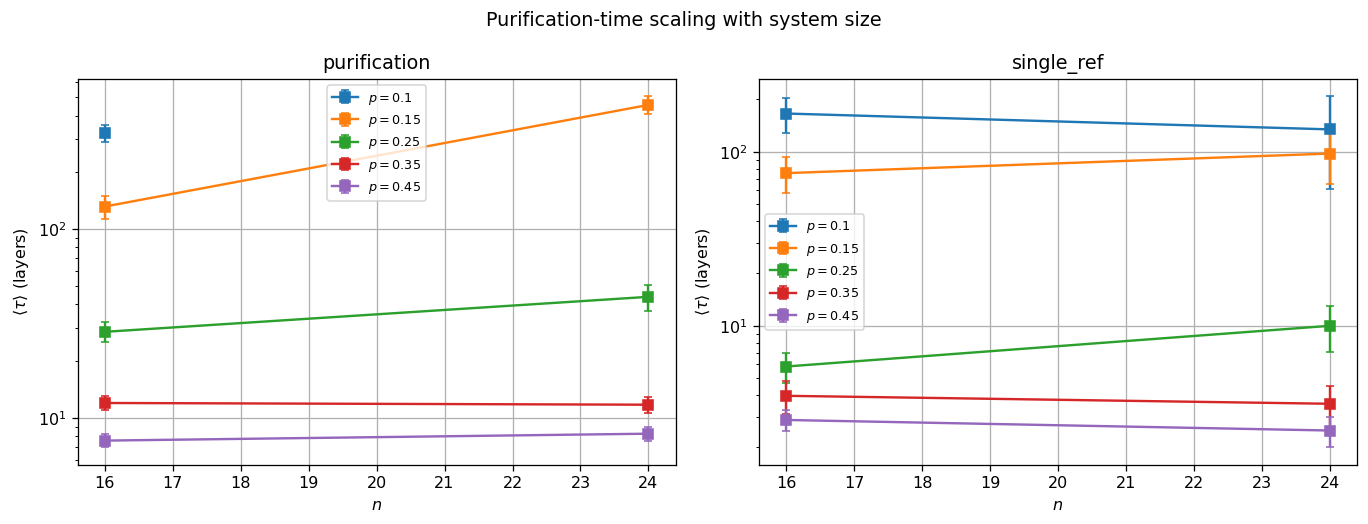

In [7]:
sel_p = [p for p in P_VALS if p in
         set(np.asarray(P_VALS)[np.linspace(0, len(P_VALS) - 1, min(5, len(P_VALS))).astype(int)])]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, pic in zip(axes, PICTURES):
    sub_pic = agg[agg["picture"] == pic]
    for p in sel_p:
        sub = sub_pic[(sub_pic["p"] == p) & sub_pic["mean_tau"].notna()].sort_values("n")
        if len(sub):
            ax.errorbar(sub["n"], sub["mean_tau"], yerr=sub["sem_tau"],
                        marker="s", capsize=2.5, label=f"$p={p}$")
    ax.set_yscale("log")
    ax.set(xlabel="$n$", ylabel=r"$\langle\tau\rangle$ (layers)", title=pic)
    ax.legend(fontsize=8)
fig.suptitle("Purification-time scaling with system size")
fig.tight_layout(); fig.savefig(FIG / "tau_vs_n.png"); plt.show()


## 8. Tableau density $\bar a$: the transition seen by the simulator

Mean active generators per qubit, normalized by $n$: extensive ($\bar a/n$
constant) in the volume-law phase, vanishing in the area-law phase, so the
curves separate exactly across the transition.

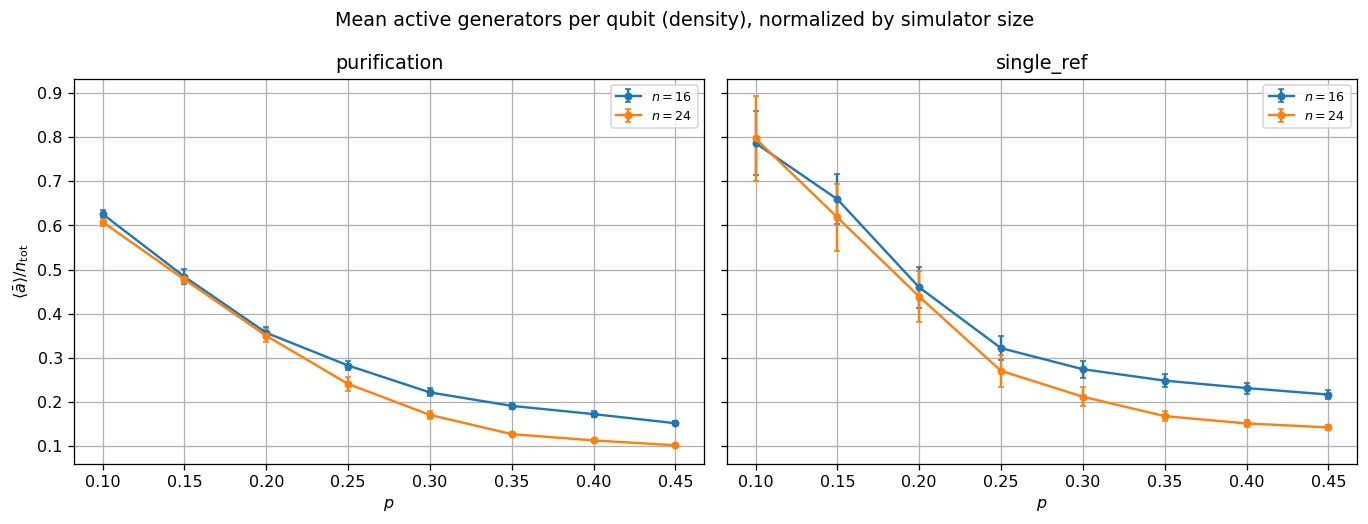

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, pic in zip(axes, PICTURES):
    sub_pic = agg[agg["picture"] == pic]
    for n_val, sub in sub_pic.groupby("n"):
        # total qubits = 2n (purification) or n+1 (single_ref); normalize by sim size
        n_tot = 2 * n_val if pic == "purification" else n_val + 1
        ax.errorbar(sub["p"], sub["mean_abar"] / n_tot, yerr=sub["sem_abar"] / n_tot,
                    marker="o", ms=4, capsize=2, label=f"$n={n_val}$")
    ax.set(xlabel="$p$", title=pic)
    ax.legend(fontsize=8)
axes[0].set_ylabel(r"$\langle\bar a\rangle / n_\mathrm{tot}$")
fig.suptitle("Mean active generators per qubit (density), normalized by simulator size")
fig.tight_layout(); fig.savefig(FIG / "abar_vs_p.png"); plt.show()


## 9. $\tau$ distributions near the transition

Full histograms at three $p$ values around the crossover for the largest $n$:
the heavy right tail near $p_c$ is why the median + IQR accompany the mean.

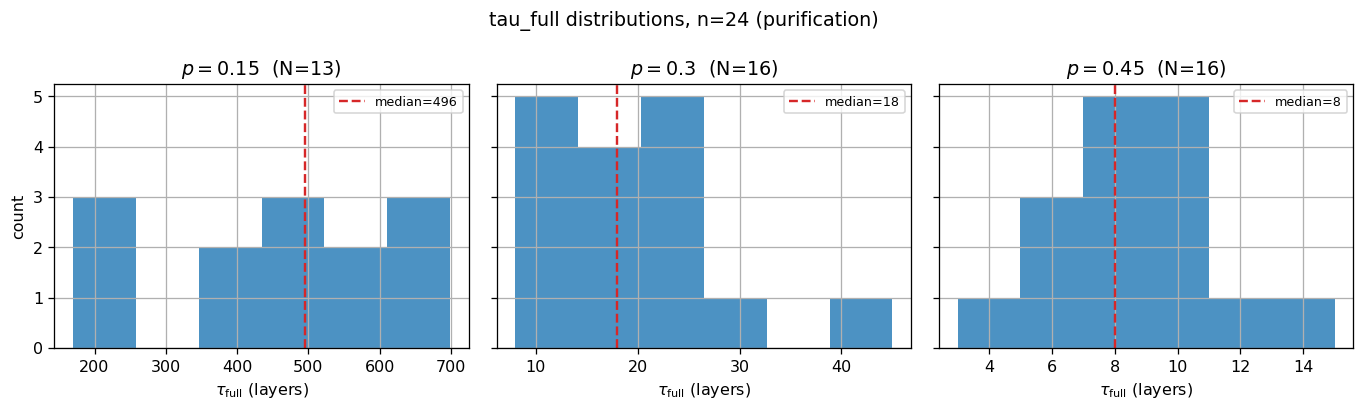

In [9]:
n_big = N_VALS[-1]
pic = "purification"
sub_df = df[(df["picture"] == pic) & (df["n"] == n_big) & df["purified"]]
have_p = sorted(sub_df["p"].unique())
pick = [have_p[i] for i in np.linspace(0, len(have_p) - 1, min(3, len(have_p))).astype(int)]
fig, axes = plt.subplots(1, len(pick), figsize=(4 * len(pick), 3.6), sharey=True)
axes = np.atleast_1d(axes)
for ax, p in zip(axes, pick):
    taus = sub_df[sub_df["p"] == p]["purified_at_layer"].to_numpy(dtype=float)
    ax.hist(taus, bins=min(30, max(6, len(taus) // 8)), color="C0", alpha=0.8)
    ax.axvline(np.median(taus), color="C3", ls="--", label=f"median={np.median(taus):.0f}")
    ax.set(title=f"$p={p}$  (N={len(taus)})", xlabel=r"$\tau_\mathrm{full}$ (layers)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("count")
fig.suptitle(f"tau_full distributions, n={n_big} ({pic})")
fig.tight_layout(); fig.savefig(FIG / "tau_distributions.png"); plt.show()


## 10. Full vs single, and the numbers for the paper

Side-by-side comparison at the largest $n$, plus the machine-readable aggregate
(`runs/paper_alltoall/aggregate.csv`) and the censoring table you should quote
alongside any below-crossover means.


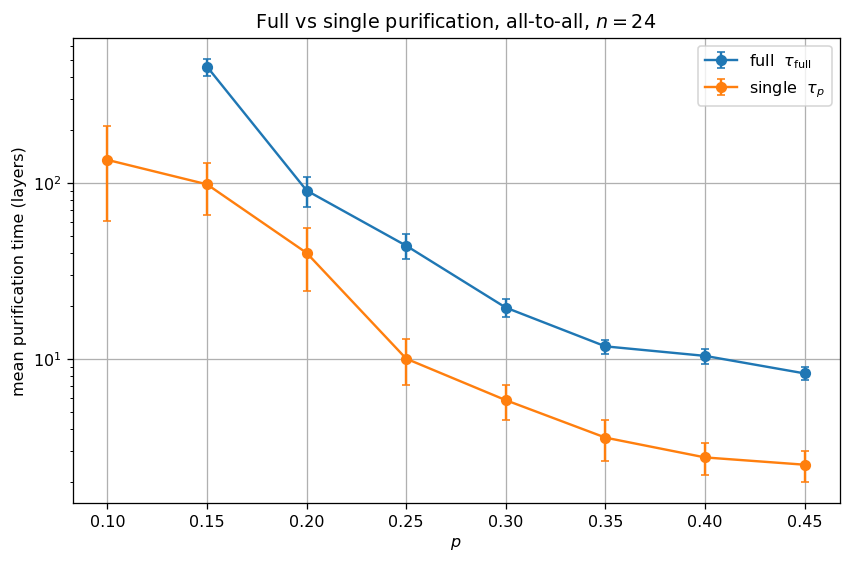

censoring (fraction purified), quote this with any low-p means:
n        16     24
p                 
0.10  0.417  0.000
0.15  1.000  0.812
0.20  1.000  1.000
0.25  1.000  1.000
0.30  1.000  1.000
0.35  1.000  1.000
0.40  1.000  1.000
0.45  1.000  1.000

figures -> runs/paper_alltoall/figures
aggregate -> runs/paper_alltoall/aggregate.csv


In [10]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for pic, lab, c in [("purification", r"full  $\tau_\mathrm{full}$", "C0"),
                    ("single_ref", r"single  $\tau_p$", "C1")]:
    sub = agg[(agg["picture"] == pic) & (agg["n"] == n_big) & agg["mean_tau"].notna()]
    ax.errorbar(sub["p"], sub["mean_tau"], yerr=sub["sem_tau"], marker="o",
                capsize=2.5, color=c, label=lab)
ax.set_yscale("log")
ax.set(xlabel="$p$", ylabel="mean purification time (layers)",
       title=f"Full vs single purification, all-to-all, $n={n_big}$")
ax.legend()
fig.tight_layout(); fig.savefig(FIG / "full_vs_single.png"); plt.show()

print("censoring (fraction purified), quote this with any low-p means:")
print(agg[agg["picture"] == "purification"]
      .pivot(index="p", columns="n", values="frac_purified").round(3))
print(f"\nfigures -> {FIG.resolve()}")
print(f"aggregate -> {(OUT / 'aggregate.csv').resolve()}")

## Production checklist

- [ ] Smoke pass (`PRODUCTION = False`) ran clean end to end.
- [ ] Calibration projection is an acceptable wall-clock; adjusted `SEEDS` /
      `P_VALS` / `DEPTH_FACTOR` if not.
- [ ] `PRODUCTION = True` run completed (or resumed); every chunk reported
      `[resume]`/`[run]` and `all chunks present`.
- [ ] `aggregate.csv` + the `figures/` folder are the paper artifacts; the
      censoring table accompanies any below-crossover claims.
- **Reproducibility**: a cell is fully determined by `(config, sample_seed)`;
  re-running any chunk reproduces it bit-for-bit. To extend statistics, raise
  `SEEDS[n]` and delete that chunk folder (or run a second study directory and
  concatenate).